# 06 Model Training

This notebook runs the current training pipeline from `src/train.py`.

Training behavior now matches the optimized codebase:

- train audio is loaded from `processed_data/train`
- waveform augmentation happens on the fly inside `tf.data`
- validation uses saved clean features from notebook 04
- the model is selected by `val_macro_f1`
- early stopping restores the best validation checkpoint
- `.keras`, `.h5`, log CSV, history JSON, and training summary are all written
        

In [1]:
from pathlib import Path
import json
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "src").exists():
        # if (candidate / "config.yaml").exists() and (candidate / "src").exists():
        # if (candidate / "configDeltaMFCC.yaml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing config.yaml and src/")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.feature_extraction import get_feature_dim
from src.model import build_bilstm_model
from src.train import build_train_dataset, run_training
from src.utils import load_config, set_seed

warnings.filterwarnings("ignore")

config = load_config(PROJECT_ROOT / "config.yaml")
# config = load_config(PROJECT_ROOT / "configDeltaMFCC.yaml")
set_seed(int(config["project"]["random_seed"]))

paths = config["paths"]
features_dir = Path(paths["features_dir"])
processed_train_dir = Path(paths["processed_data_dir"]) / "train"
models_dir = Path(paths["models_dir"])
outputs_dir = Path(paths["outputs_dir"])

with open(features_dir / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(features_dir / "label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

max_frames = int(np.load(features_dir / "max_frames.npy").squeeze())
X_val = np.load(features_dir / "X_val.npy")
y_val = np.load(features_dir / "y_val.npy")
feature_dim = get_feature_dim(config["features"])
num_classes = int(config["model"]["num_classes"])

train_files = sorted(processed_train_dir.glob("*.wav"))
train_paths = np.array([str(path) for path in train_files], dtype=np.str_)
train_labels = np.array(
    [int(label_encoder.transform([path.name.split("-")[1]])[0]) for path in train_files],
    dtype=np.int32,
)

print("TensorFlow version:", tf.__version__)
print("Train files:", len(train_files))
print("Validation tensor shape:", X_val.shape)
display(pd.DataFrame([{
    "batch_size": int(config["training"]["batch_size"]),
    "epochs": int(config["training"]["epochs"]),
    "checkpoint_monitor": config["training"]["checkpoint_monitor"],
    "temporal_pooling": config["model"].get("temporal_pooling", "last"),
    "feature_dim": feature_dim,
    "max_frames": max_frames,
}]))
        

TensorFlow version: 2.21.0
Train files: 840
Validation tensor shape: (180, 119, 120)


,batch_size,epochs,checkpoint_monitor,temporal_pooling,feature_dim,max_frames
0,32,150,val_macro_f1,attention,120,119


In [2]:
train_ds = build_train_dataset(
    train_paths=train_paths,
    train_labels=train_labels,
    scaler=scaler,
    max_frames=max_frames,
    feature_dim=feature_dim,
    num_classes=num_classes,
    feat_cfg=config["features"],
    aug_cfg=config["augmentation"],
    batch_size=int(config["training"]["batch_size"]),
    seed=int(config["project"]["random_seed"]),
)

batch_x, batch_y = next(iter(train_ds.take(1)))
print("One training batch X shape:", batch_x.shape)
print("One training batch y shape:", batch_y.shape)
        

One training batch X shape: (32, 119, 120)
One training batch y shape: (32, 5)


In [3]:
model = build_bilstm_model(
    input_shape=(max_frames, feature_dim),
    config=config,
)
print("Model parameters:", model.count_params())
model.summary()
        


Model parameters: 576070


Model: "SER_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 119, 120)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_padding        │ (None, 119, 120)  │          0 │ input_features[0… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 119, 120)  │          0 │ input_features[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 119, 120)  │          0 │ mask_padding[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 119)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 119, 256)  │    254,976 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 119, 192)  │    271,104 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_pool      │ (None, 192)       │     12,417 │ bilstm_2[0][0],   │
│ (MaskedAttentionPo… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     24,704 │ attention_pool[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │     12,384 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 5)         │        485 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 576,070 (2.20 MB)

 Trainable params: 576,070 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

## Run Training

The next cell calls `src.train.run_training(config)`, which is the same path used by the CLI entry point.

Outputs written by the training pipeline:

- `models/best_model.keras`
- `models/best_model.h5`
- `models/training_log.csv`
- `models/training_history.json`
- `models/training_summary.json`
- `outputs/training_history.png`
        

In [4]:
run_training(config)
print("Training completed.")
        

2026-03-23 21:34:15 | INFO | ser.train | Model parameters: 576070


Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1945 - loss: 1.6351 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_macro_f1: 0.1757
Epoch 1: val_macro_f1 improved from None to 0.17571, saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5



Epoch 1: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.1940 - loss: 1.6367 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2389 - val_loss: 1.6191 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_macro_f1: 0.1757 - learning_rate: 4.0000e-04
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2199 - loss: 1.6263 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_macro_f1: 0.2335
Epoch 2: val_macro_f1 improved from 0.17571 to 0.23354, saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5



Epoch 2: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.2286 - loss: 1.6239 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2722 - val_loss: 1.5950 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_macro_f1: 0.2335 - learning_rate: 4.0000e-04
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2443 - loss: 1.6167 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_macro_f1: 0.2211
Epoch 3: val_macro_f1 did not improve from 0.23354
27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.2619 - loss: 1.6103 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2667 - val_loss: 1.5599 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_macro_f1: 0.2211 - learning_rate: 4.0000e-04
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3201 - loss: 1.5747 - precision: 0.7963 - recall: 0.0025 - val_macro_f1: 0.2705
Epoch 4: val_macro_f1 improved from 0.


Epoch 4: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.3250 - loss: 1.5727 - precision: 0.7500 - recall: 0.0036 - val_accuracy: 0.3167 - val_loss: 1.5284 - val_precision: 0.5556 - val_recall: 0.0278 - val_macro_f1: 0.2705 - learning_rate: 4.0000e-04
Epoch 5/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3525 - loss: 1.5481 - precision: 0.3076 - recall: 0.0064 - val_macro_f1: 0.3022
Epoch 5: val_macro_f1 improved from 0.27047 to 0.30220, saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5


...


Epoch 39: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7488 - loss: 0.8683 - precision: 0.8328 - recall: 0.6405 - val_accuracy: 0.7333 - val_loss: 0.9963 - val_precision: 0.7545 - val_recall: 0.7000 - val_macro_f1: 0.7332 - learning_rate: 4.0000e-04
Epoch 40/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7651 - loss: 0.8443 - precision: 0.8361 - recall: 0.6708 - val_macro_f1: 0.6649
Epoch 40: val_macro_f1 did not improve from 0.73320
27/27 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7464 - loss: 0.8679 - precision: 0.8159 - recall: 0.6488 - val_accuracy: 0.6722 - val_loss: 1.0761 - val_precision: 0.7134 - val_recall: 0.6222 - val_macro_f1: 0.6649 - learning_rate: 4.0000e-04
Epoch 41/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7505 - loss: 0.8531 - precision: 0.8212 - recall: 0.6495 - val_macro_f1: 0.6933
Epoch 41: val_macro_f1 did not improve from 0.73320
27/27 ━━━━━━━━━━━━━━━━


Epoch 49: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7762 - loss: 0.8068 - precision: 0.8273 - recall: 0.6786 - val_accuracy: 0.7444 - val_loss: 0.9764 - val_precision: 0.7870 - val_recall: 0.7389 - val_macro_f1: 0.7386 - learning_rate: 2.0000e-04
Epoch 50/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8252 - loss: 0.7615 - precision: 0.8898 - recall: 0.7295 - val_macro_f1: 0.7078
Epoch 50: val_macro_f1 did not improve from 0.73856
27/27 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8179 - loss: 0.7724 - precision: 0.8775 - recall: 0.7250 - val_accuracy: 0.7111 - val_loss: 0.9913 - val_precision: 0.7485 - val_recall: 0.6944 - val_macro_f1: 0.7078 - learning_rate: 2.0000e-04
Epoch 51/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8181 - loss: 0.7885 - precision: 0.8732 - recall: 0.7213 - val_macro_f1: 0.7177
Epoch 51: val_macro_f1 did not improve from 0.73856
27/27 ━━━━━━━━━━━━━━━━


Epoch 60: finished saving model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8321 - loss: 0.7459 - precision: 0.8767 - recall: 0.7619 - val_accuracy: 0.7500 - val_loss: 0.9932 - val_precision: 0.7602 - val_recall: 0.7222 - val_macro_f1: 0.7449 - learning_rate: 5.0000e-05
Epoch 61/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8282 - loss: 0.7433 - precision: 0.8870 - recall: 0.7772 - val_macro_f1: 0.7400
Epoch 61: val_macro_f1 did not improve from 0.74488
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8381 - loss: 0.7345 - precision: 0.9006 - recall: 0.7762 - val_accuracy: 0.7444 - val_loss: 0.9935 - val_precision: 0.7647 - val_recall: 0.7222 - val_macro_f1: 0.7400 - learning_rate: 5.0000e-05
Epoch 62/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8561 - loss: 0.7042 - precision: 0.9013 - recall: 0.7806 - val_macro_f1: 0.7289
Epoch 62: val_macro_f1 did not improve from 0.74488
27/27 ━━━━━━━━━━━━━━━━

2026-03-23 22:39:41 | INFO | ser.train | Validation summary | acc=0.7500 | macro_f1=0.7449 | best_epoch=60
INFO:ser.train:Validation summary | acc=0.7500 | macro_f1=0.7449 | best_epoch=60
2026-03-23 22:39:42 | INFO | ser.train | Saved model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
INFO:ser.train:Saved model to D:\Skripsi\Testing\Model_SERv4\models\best_model.h5
2026-03-23 22:39:42 | INFO | ser.train | Saved features/scaler.pkl and features/label_encoder.pkl are expected prerequisites.
INFO:ser.train:Saved features/scaler.pkl and features/label_encoder.pkl are expected prerequisites.


Training completed.


In [5]:
training_summary = json.loads((models_dir / "training_summary.json").read_text(encoding="utf-8"))
training_history = json.loads((models_dir / "training_history.json").read_text(encoding="utf-8"))

display(pd.DataFrame([training_summary]))
print("History keys:", sorted(training_history.keys()))
        

,best_epoch,best_val_macro_f1_observed,best_val_accuracy_observed,restored_val_accuracy,restored_val_macro_precision,restored_val_macro_recall,restored_val_macro_f1,feature_dim,max_frames
0,60,0.744877,0.75,0.75,0.753043,0.75,0.744877,120,119


History keys: ['accuracy', 'learning_rate', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_macro_f1', 'val_precision', 'val_recall']


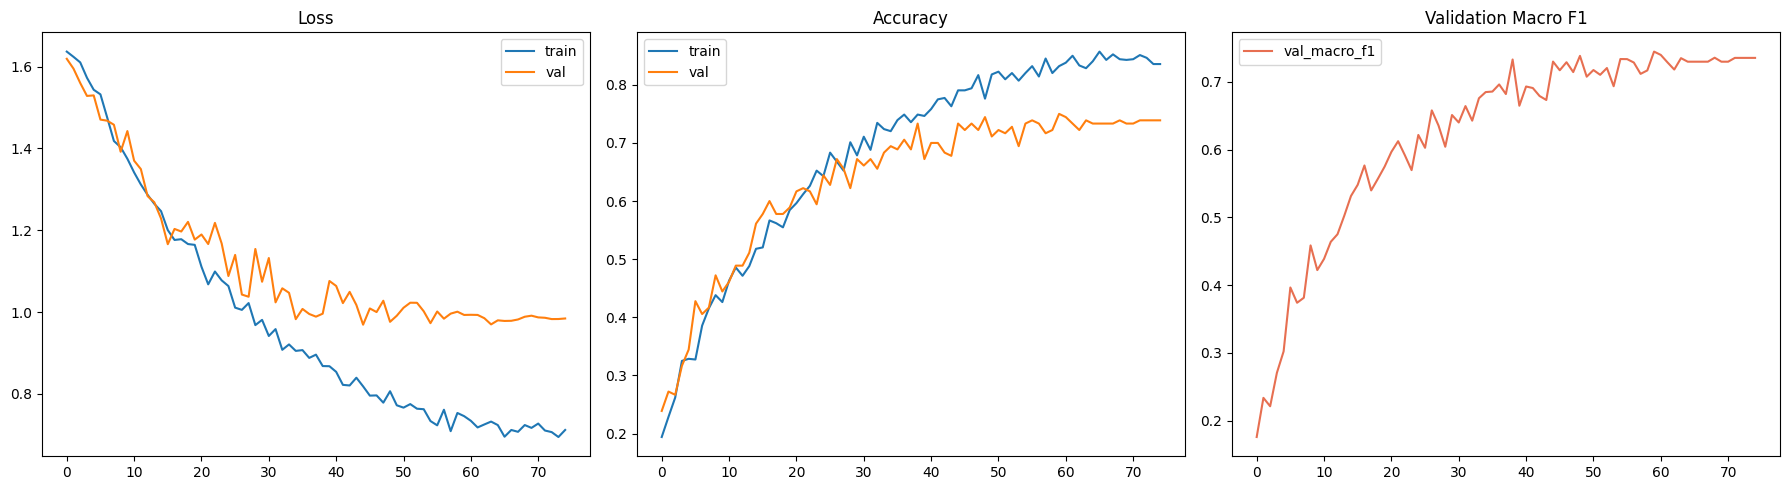

In [6]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(training_history.get("loss", []), label="train")
plt.plot(training_history.get("val_loss", []), label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(training_history.get("accuracy", []), label="train")
plt.plot(training_history.get("val_accuracy", []), label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(training_history.get("val_macro_f1", []), label="val_macro_f1", color="#e76f51")
plt.title("Validation Macro F1")
plt.legend()

plt.tight_layout()
plt.show()
        

In [7]:
required_artifacts = [
    models_dir / "best_model.keras",
    models_dir / "best_model.h5",
    models_dir / "training_log.csv",
    models_dir / "training_history.json",
    models_dir / "training_summary.json",
    outputs_dir / "training_history.png",
]

artifact_status = pd.DataFrame(
    [{"artifact": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()} for path in required_artifacts]
)
display(artifact_status)
        

,artifact,exists
0,models\best_model.keras,True
1,models\best_model.h5,True
2,models\training_log.csv,True
3,models\training_history.json,True
4,models\training_summary.json,True
5,outputs\training_history.png,True


## Selection Rule

The saved model is the checkpoint that maximized validation macro F1, not the last epoch and not the test set.

Notebook 07 will load the saved checkpoint and evaluate it on the held-out test features.
        